<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Project_4_Skin_Lesion_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin Lesion Classification

# Upload Kaggle API Token

In [4]:
# Creating kaggle.json
import json

kaggle_dict = {
    "username": "bilaldataikhaliq86",
    "key": "KGAT_5f92e278fb971940e257a07fcab15311"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_dict, f)

print("kaggle.json file created")

kaggle.json file created


In [5]:
# Moving the File
import os
import shutil

# Creating a folder
os.makedirs("/root/.kaggle", exist_ok=True)

# Moving the file
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

# Setting permission
os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle setup complete")

Kaggle setup complete


In [1]:
from google.colab import files
uploaded = files.upload()  # Upload kaggle.json here

# Step 2: Setup Kaggle API

In [6]:
!pip install -q kaggle

In [7]:
# Testing
!kaggle datasets list

ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                     Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000           6868        173                1  
nalisha/job-salary-prediction-dataset                              Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          13492        306                1  
sohaibdevv/ai-and-student-life-2026-the-new-normal                 How AI is Changing Life | AI and Student Life 2026       21917  2026-04-11 11:52:06.050000            643         23     

# Step 3: Download Dataset

In [8]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 --unzip

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:44<00:00, 127MB/s]



In [9]:
import os
print(os.listdir())

['.config', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_2', 'hmnist_8_8_RGB.csv', 'HAM10000_images_part_2', 'HAM10000_metadata.csv', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'hmnist_28_28_L.csv', 'sample_data']


# Step 4: Import Libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Step 5: Load Metadata

In [11]:
df = pd.read_csv("HAM10000_metadata.csv")
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## Step 6: Label Mapping

In [12]:
label_map = {
    "akiec": 0,
    "bcc": 1,
    "bkl": 2,
    "df": 3,
    "mel": 4,
    "nv": 5,
    "vasc": 6
}

df['label'] = df['dx'].map(label_map)

df[['dx', 'label']].head()

,dx,label
0,bkl,2
1,bkl,2
2,bkl,2
3,bkl,2
4,bkl,2


# Load and Preprocess Images

In [13]:
import os
import cv2
import numpy as np

# Correct folders
folders = ['HAM10000_images_part_1', 'HAM10000_images_part_2']

# Create image path dictionary
image_paths = []
for folder in folders:
    for file in os.listdir(folder):
        image_paths.append(os.path.join(folder, file))

image_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in image_paths}

# Load images
images = []
labels = []

for _, row in df.iterrows():
    img_path = image_dict[row['image_id']]
    img = cv2.imread(img_path)

    # Resize image
    img = cv2.resize(img, (64, 64))

    images.append(img)
    labels.append(row['label'])

# Convert to arrays
X = np.array(images) / 255.0
y = np.array(labels)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (10015, 64, 64, 3)
Shape of y: (10015,)


# One-Hot Encoding + Train-Test Split

In [14]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

y = to_categorical(y, num_classes=7)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Validation samples:", X_val.shape)

Training samples: (8012, 64, 64, 3)
Validation samples: (2003, 64, 64, 3)


# Build CNN Model

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,055 (6.20 MB)

 Trainable params: 1,626,055 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

# Train Model

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_val, y_val)
)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 61s 235ms/step - accuracy: 0.6654 - loss: 1.0418 - val_accuracy: 0.6800 - val_loss: 0.9223
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 71s 193ms/step - accuracy: 0.6794 - loss: 0.9257 - val_accuracy: 0.6665 - val_loss: 0.8747
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 91s 227ms/step - accuracy: 0.6850 - loss: 0.8780 - val_accuracy: 0.6940 - val_loss: 0.8511
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 50s 199ms/step - accuracy: 0.6912 - loss: 0.8320 - val_accuracy: 0.6955 - val_loss: 0.8357
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 82s 199ms/step - accuracy: 0.6985 - loss: 0.8098 - val_accuracy: 0.7034 - val_loss: 0.8059


# Evaluate & Plot

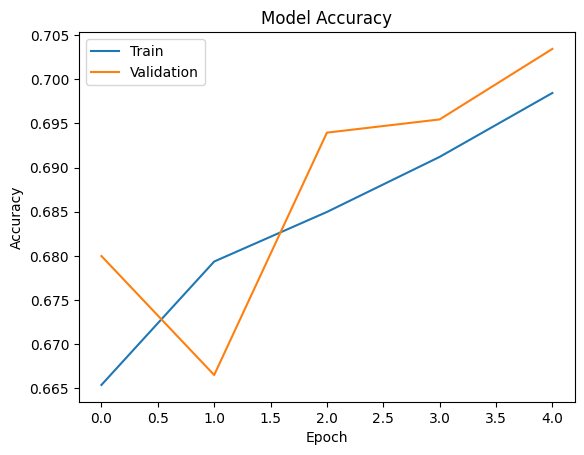

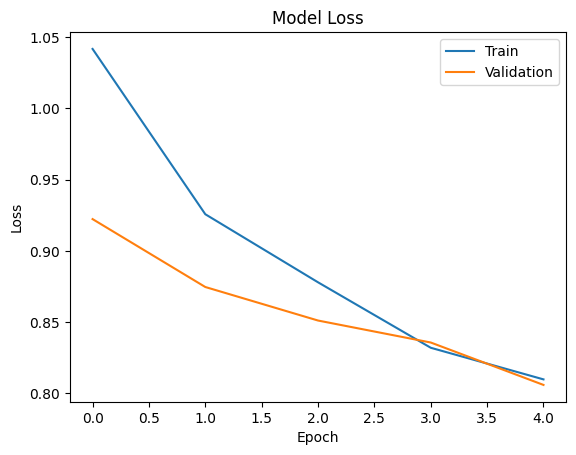

In [17]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# Transfer Learning (VGG16)

In [18]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(64,64,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(7, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977,863 (57.14 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [19]:
# Train Transfer Model
transfer_model.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_val, y_val)
)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 550s 2s/step - accuracy: 0.6867 - loss: 0.9201 - val_accuracy: 0.7009 - val_loss: 0.8439
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 553s 2s/step - accuracy: 0.7208 - loss: 0.7827 - val_accuracy: 0.7169 - val_loss: 0.7867
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 493s 2s/step - accuracy: 0.7391 - loss: 0.7299 - val_accuracy: 0.7214 - val_loss: 0.7804
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 535s 2s/step - accuracy: 0.7534 - loss: 0.6920 - val_accuracy: 0.6860 - val_loss: 0.8356
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 501s 2s/step - accuracy: 0.7580 - loss: 0.6816 - val_accuracy: 0.7244 - val_loss: 0.7556


# Test with Uploaded Image

In [20]:
from google.colab import files
import numpy as np
import cv2

uploaded = files.upload()

for file in uploaded.keys():
    img = cv2.imread(file)
    img = cv2.resize(img, (64,64))
    img = img / 255.0
    img = np.reshape(img, (1,64,64,3))

    pred = model.predict(img)
    class_index = np.argmax(pred)

    print("Predicted Class:", class_index)

Saving ISIC_0029306.jpg to ISIC_0029306.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Predicted Class: 5


# Adding label names

In [21]:
class_names = [
    "Actinic Keratoses",
    "Basal Cell Carcinoma",
    "Benign Keratosis",
    "Dermatofibroma",
    "Melanoma",
    "Melanocytic Nevi",
    "Vascular Lesions"
]

print("Predicted:", class_names[class_index])

Predicted: Melanocytic Nevi
